<a href="https://colab.research.google.com/github/sun-mengwei/dtb-colab-experiments/blob/elliptic-pde/dtb_elliptic_single_mode_dimensions_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DTB--Ritz single-mode Poisson in 2D, 5D, and 10D

On $[-1,1]^d$, the manufactured reference is
$$u_*(x)=\prod_{j=1}^d\cos(\pi x_j/2),\qquad f=(d\pi^2/4)u_*.$$
The exact boundary factor is tested as dimension grows. Here 'time' means outer DTB iteration: snapshots compare the fixed reference solution with the current DTB diagonal slice.

In [1]:
# Clone the requested branch when running in a fresh Colab session.
import os, subprocess
from pathlib import Path
if Path('DTB_elliptic_utils.py').exists():
    ROOT = Path.cwd()
else:
    ROOT = Path('/content/dtb-colab-experiments')
    if not ROOT.exists():
        subprocess.run(['git', 'clone', '-b', 'elliptic-pde', 'https://github.com/sun-mengwei/dtb-colab-experiments.git', str(ROOT)], check=True)
    os.chdir(ROOT)
print('repository:', ROOT)

repository: /content/dtb-colab-experiments


In [2]:
# Shared DTB mechanics live in one concise utility module.
import math
import matplotlib.pyplot as plt
import numpy as np
import torch
from DTB_elliptic_utils import (MLP, armijo_update, direct_ritz_energy, envelope_gradient, expand_direction, flatten_parameters, make_box_trial, matrix_ritz_energy, predict_tangent, relative_l2_error, sample_box, sample_box_boundary, select_parameter_indices, solve_tangent_ritz, summarize_history)

torch.set_default_dtype(torch.float64)
DEVICE = torch.device('cpu')
CASES = [
    dict(d=2, train=512, valid=2048, outer=30),
    dict(d=5, train=512, valid=2048, outer=20),
    dict(d=10, train=768, valid=2048, outer=12),
]
WIDTH, DEPTH, TANGENT_DIM = 16, 2, 32
RIDGE_RELATIVE, INITIAL_STEP = 1e-4, 1.0

## Runner

Every outer iteration rebuilds the selected tangent basis, solves the inner Ritz system, records only $L^2$, $F(\theta)$, inner residual, and $\|\alpha\|_2$, then takes an envelope-gradient step. The plotted $F(\theta)$ is the unregularized empirical Ritz energy; the small ridge only stabilizes the inner linear solve.

In [3]:
results = {}
for cfg in CASES:
    d, outer_steps = cfg['d'], cfg['outer']
    torch.manual_seed(100 + d)
    model = MLP(d, width=WIDTH, depth=DEPTH).to(DEVICE)
    theta, spec = flatten_parameters(model)
    theta = theta.to(DEVICE)
    trial = make_box_trial(model, spec, normalize_boundary=True)
    indices = select_parameter_indices(theta.numel(), min(TANGENT_DIM, theta.numel()), 700 + d)
    volume = 2.0 ** d

    def exact(point):
        return torch.prod(torch.cos(0.5 * math.pi * point), dim=-1)

    x_train = sample_box(cfg['train'], d, 10 + d, device=DEVICE)
    x_valid = sample_box(cfg['valid'], d, 20 + d, device=DEVICE)
    f_train = (d * math.pi**2 / 4.0) * exact(x_train)
    snapshot_steps = {0, outer_steps // 2, outer_steps}
    diagonal = torch.linspace(-1, 1, 301)[:, None].repeat(1, d)
    history, snapshots = [], {}

    for step in range(outer_steps + 1):
        solution, stiffness, load = solve_tangent_ritz(
            trial, theta, indices, x_train, f_train, volume,
            ridge_relative=RIDGE_RELATIVE,
        )
        direction = expand_direction(solution.alpha, indices, theta.numel())
        F_theta = float(matrix_ritz_energy(stiffness, load, solution.alpha))
        row = dict(
            step=step, F_theta=F_theta,
            relative_l2=relative_l2_error(trial, theta, direction, x_valid, exact),
            inner_residual=solution.relative_residual,
            alpha_norm=float(torch.linalg.norm(solution.alpha)),
        )
        history.append(row)
        if step in snapshot_steps:
            snapshots[step] = predict_tangent(trial, theta, direction, diagonal).detach().cpu().numpy()
        if step == outer_steps:
            break

        # Alpha is fixed in this outer derivative (envelope step).
        gradient = envelope_gradient(trial, theta, direction, x_train, f_train, volume)
        fixed_objective = lambda th: direct_ritz_energy(trial, th, direction.detach(), x_train, f_train, volume)
        theta, _ = armijo_update(fixed_objective, theta, gradient, initial_step=INITIAL_STEP)

    boundary = sample_box_boundary(64, d, 900 + d)
    boundary_max = float(predict_tangent(trial, theta, direction, boundary).abs().max())

    # Final-solution data for complementary slice diagnostics.
    s = torch.linspace(-1.0, 1.0, 301, device=DEVICE)
    axis_predictions = []
    for coordinate in range(d):
        axis_points = torch.zeros(s.numel(), d, device=DEVICE)
        axis_points[:, coordinate] = s
        axis_predictions.append(predict_tangent(trial, theta, direction, axis_points).detach().cpu().numpy())
    axis_reference = torch.cos(0.5 * math.pi * s).cpu().numpy()

    rho = torch.linspace(-math.sqrt(d), math.sqrt(d), 301, device=DEVICE)
    rescaled_points = (rho[:, None] / math.sqrt(d)).repeat(1, d)
    rescaled_prediction = predict_tangent(trial, theta, direction, rescaled_points).detach().cpu().numpy()
    rescaled_reference = exact(rescaled_points).cpu().numpy()

    plane_coordinate = torch.linspace(-1.0, 1.0, 81, device=DEVICE)
    plane_s, plane_t = torch.meshgrid(plane_coordinate, plane_coordinate, indexing='ij')
    plane_points = torch.zeros(plane_s.numel(), d, device=DEVICE)
    plane_points[:, 0], plane_points[:, 1] = plane_s.ravel(), plane_t.ravel()
    plane_prediction = predict_tangent(trial, theta, direction, plane_points).detach().cpu().numpy().reshape(81, 81)
    plane_reference = exact(plane_points).cpu().numpy().reshape(81, 81)

    random_generator = torch.Generator(device=DEVICE).manual_seed(1200 + d)
    random_directions = torch.randn(4, d, generator=random_generator, device=DEVICE)
    random_directions /= random_directions.abs().amax(dim=1, keepdim=True)
    random_predictions, random_references = [], []
    for q in random_directions:
        random_points = s[:, None] * q[None, :]
        random_predictions.append(predict_tangent(trial, theta, direction, random_points).detach().cpu().numpy())
        random_references.append(exact(random_points).cpu().numpy())

    # x_valid is independent of the training sample and is reused for test diagnostics.
    test_prediction = predict_tangent(trial, theta, direction, x_valid).detach().cpu().numpy()
    test_reference = exact(x_valid).cpu().numpy()
    results[d] = dict(
        history=history, snapshots=snapshots, diagonal=diagonal[:, 0].numpy(), boundary_max=boundary_max,
        axis=dict(s=s.cpu().numpy(), prediction=np.stack(axis_predictions), reference=axis_reference),
        rescaled=dict(rho=rho.cpu().numpy(), prediction=rescaled_prediction, reference=rescaled_reference),
        plane=dict(coordinate=plane_coordinate.cpu().numpy(), prediction=plane_prediction, reference=plane_reference),
        random=dict(s=s.cpu().numpy(), directions=random_directions.cpu().numpy(), prediction=np.stack(random_predictions), reference=np.stack(random_references)),
        test=dict(reference=test_reference, prediction=test_prediction, boundary_distance=(1.0 - x_valid.abs().amax(dim=1)).cpu().numpy(), normalized_radius=(torch.linalg.norm(x_valid, dim=1) / math.sqrt(d)).cpu().numpy()),
    )
    print(f'\n--- d={d}: max |u_DTB| on sampled boundary = {boundary_max:.3e} ---')
    summarize_history([history[0], history[len(history)//2], history[-1]])


--- d=2: max |u_DTB| on sampled boundary = 0.000e+00 ---
step=  0  F(theta)=-2.467e+00  rel-L2=5.405e-03  inner-res=1.9e-16  ||alpha||=2.81e+00
step= 15  F(theta)=-2.467e+00  rel-L2=5.455e-03  inner-res=2.1e-16  ||alpha||=2.77e+00
step= 30  F(theta)=-2.467e+00  rel-L2=5.504e-03  inner-res=2.0e-16  ||alpha||=2.74e+00

--- d=5: max |u_DTB| on sampled boundary = 0.000e+00 ---
step=  0  F(theta)=-6.987e+00  rel-L2=1.495e-01  inner-res=3.5e-16  ||alpha||=1.43e+01
step= 10  F(theta)=-7.006e+00  rel-L2=1.526e-01  inner-res=4.5e-16  ||alpha||=1.53e+01
step= 20  F(theta)=-7.026e+00  rel-L2=1.556e-01  inner-res=4.1e-16  ||alpha||=1.63e+01

--- d=10: max |u_DTB| on sampled boundary = 0.000e+00 ---
step=  0  F(theta)=-7.852e+00  rel-L2=3.389e-01  inner-res=1.1e-15  ||alpha||=3.96e+00
step=  6  F(theta)=-7.901e+00  rel-L2=3.401e-01  inner-res=7.8e-16  ||alpha||=4.11e+00
step= 12  F(theta)=-7.940e+00  rel-L2=3.416e-01  inner-res=1.1e-15  ||alpha||=4.17e+00


## Reference-versus-DTB snapshots

The black reference curve is static because the PDE is stationary; colored curves show DTB at selected outer iterations.

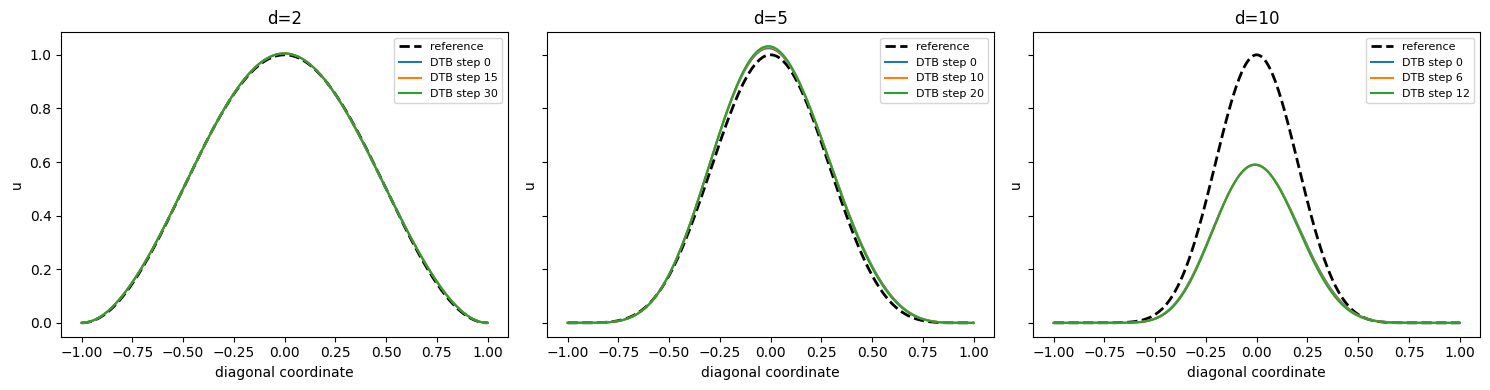

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for axis, (d, result) in zip(axes, results.items()):
    t = result['diagonal']
    reference = np.cos(0.5 * np.pi * t) ** d
    axis.plot(t, reference, 'k--', lw=2, label='reference')
    for step, values in result['snapshots'].items():
        axis.plot(t, values, label=f'DTB step {step}')
    axis.set(title=f'd={d}', xlabel='diagonal coordinate', ylabel='u')
    axis.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Complementary slice diagnostics

A main-diagonal slice can hide directional errors. The final DTB approximation is therefore also checked on every coordinate axis $x=s e_i$, the norm-rescaled diagonal $x=(\rho/\sqrt d)\mathbf 1$, and four reproducible random directions $x=sq$ with $\|q\|_\infty=1$. Solid curves are DTB and dashed curves are the manufactured reference.

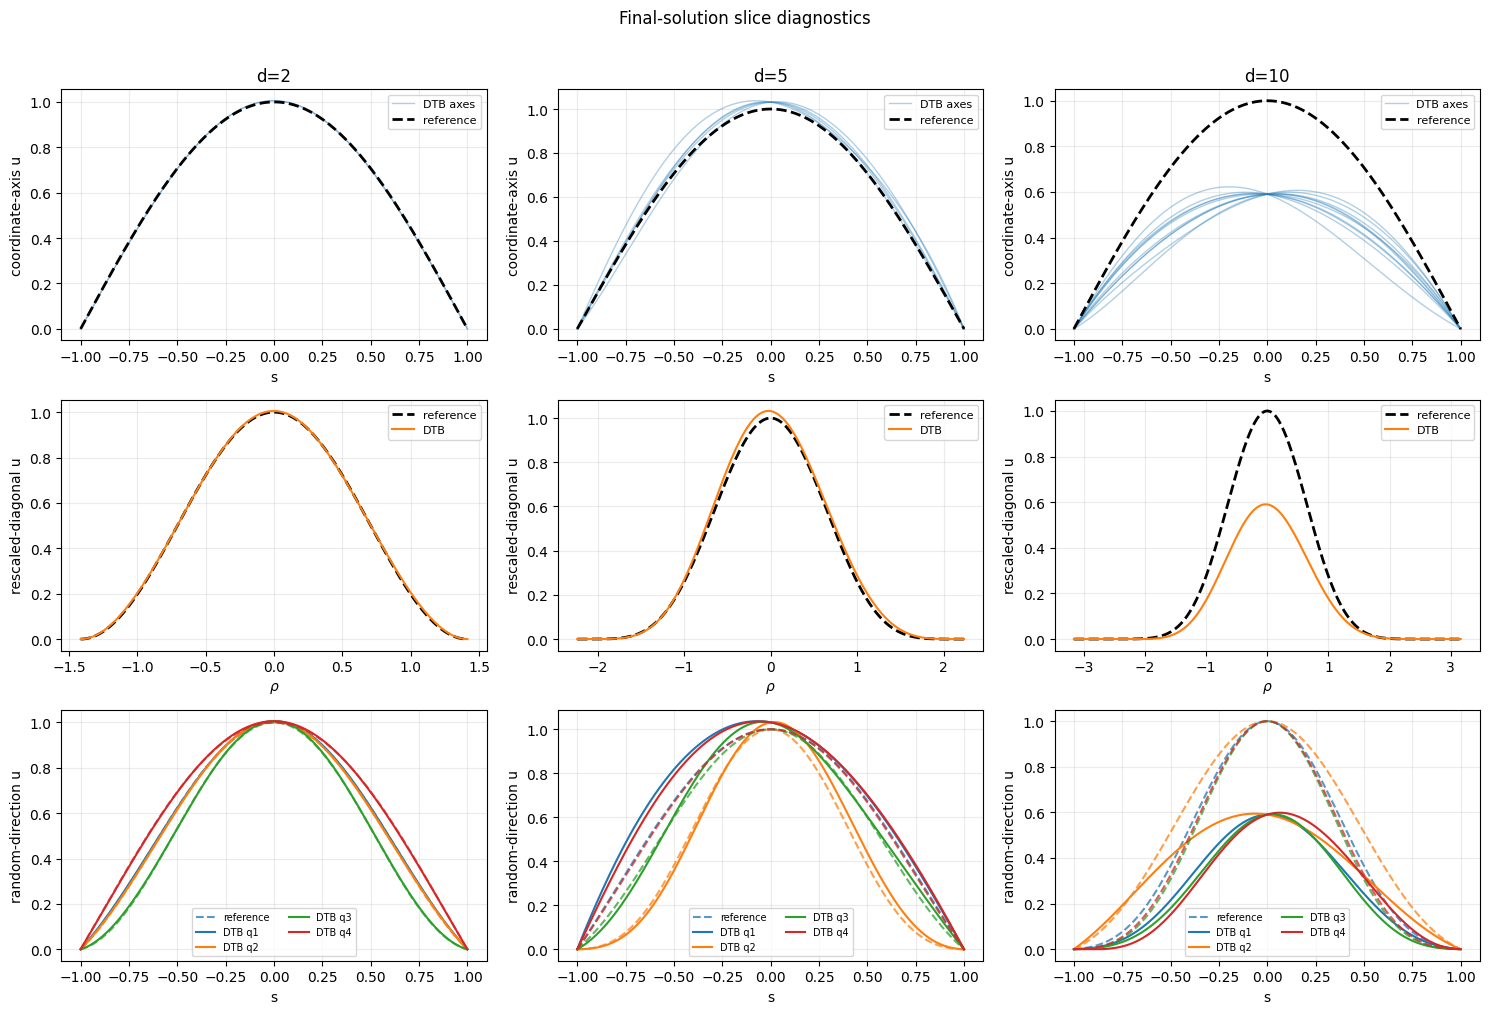

In [5]:
fig, axes = plt.subplots(3, len(results), figsize=(15, 10))
for column, (d, result) in enumerate(results.items()):
    axis_data = result['axis']
    for coordinate, values in enumerate(axis_data['prediction']):
        axes[0, column].plot(axis_data['s'], values, color='C0', alpha=.35, lw=1, label='DTB axes' if coordinate == 0 else None)
    axes[0, column].plot(axis_data['s'], axis_data['reference'], 'k--', lw=2, label='reference')
    axes[0, column].set(title=f'd={d}', xlabel='s', ylabel='coordinate-axis u')
    axes[0, column].legend(fontsize=8)

    rescaled = result['rescaled']
    axes[1, column].plot(rescaled['rho'], rescaled['reference'], 'k--', lw=2, label='reference')
    axes[1, column].plot(rescaled['rho'], rescaled['prediction'], color='C1', label='DTB')
    axes[1, column].set(xlabel=r'$\rho$', ylabel='rescaled-diagonal u')
    axes[1, column].legend(fontsize=8)

    random_data = result['random']
    for k, (prediction, reference) in enumerate(zip(random_data['prediction'], random_data['reference'])):
        color = f'C{k}'
        axes[2, column].plot(random_data['s'], reference, '--', color=color, alpha=.75, label='reference' if k == 0 else None)
        axes[2, column].plot(random_data['s'], prediction, color=color, label=f'DTB q{k + 1}')
    axes[2, column].set(xlabel='s', ylabel='random-direction u')
    axes[2, column].legend(fontsize=7, ncol=2)

for axis in axes.flat:
    axis.grid(alpha=.25)
fig.suptitle('Final-solution slice diagnostics', y=1.01)
plt.tight_layout(); plt.show()

## Coordinate-plane diagnostic

The plane $x=(s,t,0,\ldots,0)$ exposes structure that no one-dimensional line can show. Each row compares the reference, final DTB approximation, and pointwise absolute error.

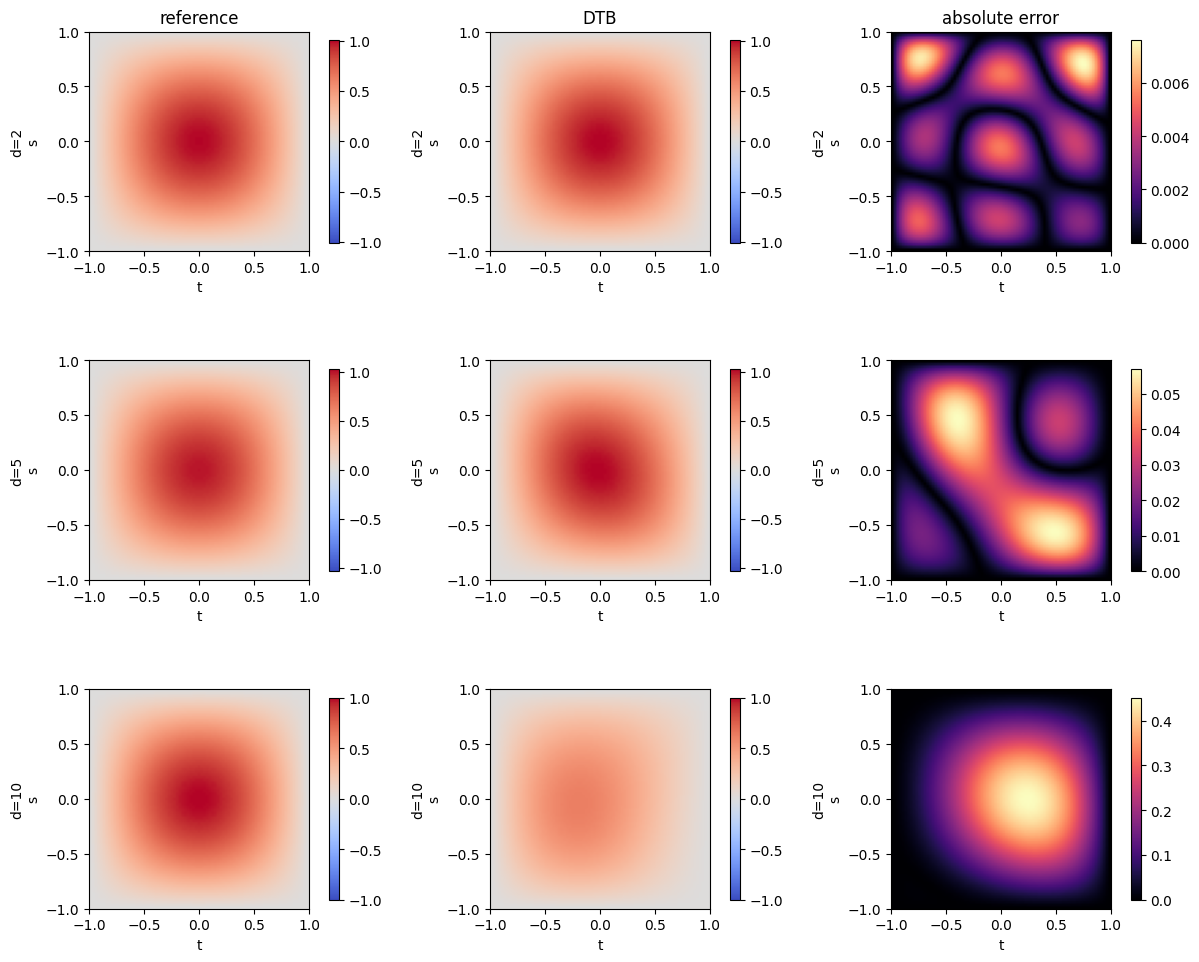

In [6]:
fig, axes = plt.subplots(len(results), 3, figsize=(12, 10), constrained_layout=True, squeeze=False)
for row, (d, result) in enumerate(results.items()):
    plane = result['plane']; reference = plane['reference']; prediction = plane['prediction']
    extent = [plane['coordinate'][0], plane['coordinate'][-1], plane['coordinate'][0], plane['coordinate'][-1]]
    solution_limit = max(np.abs(reference).max(), np.abs(prediction).max())
    images = [
        axes[row, 0].imshow(reference, origin='lower', extent=extent, vmin=-solution_limit, vmax=solution_limit, cmap='coolwarm'),
        axes[row, 1].imshow(prediction, origin='lower', extent=extent, vmin=-solution_limit, vmax=solution_limit, cmap='coolwarm'),
        axes[row, 2].imshow(np.abs(prediction - reference), origin='lower', extent=extent, vmin=0.0, cmap='magma'),
    ]
    for column, image in enumerate(images):
        axes[row, column].set(xlabel='t', ylabel=f'd={d}\ns', aspect='equal')
        fig.colorbar(image, ax=axes[row, column], fraction=.046, pad=.04)
for column, title in enumerate(['reference', 'DTB', 'absolute error']):
    axes[0, column].set_title(title)
plt.show()

## Independent-test diagnostics

Using the held-out Sobol sample, the plots below show prediction parity, absolute error versus exact amplitude, and binned RMSE versus both boundary distance $\delta(x)=1-\|x\|_\infty$ and normalized radius $\|x\|_2/\sqrt d$.

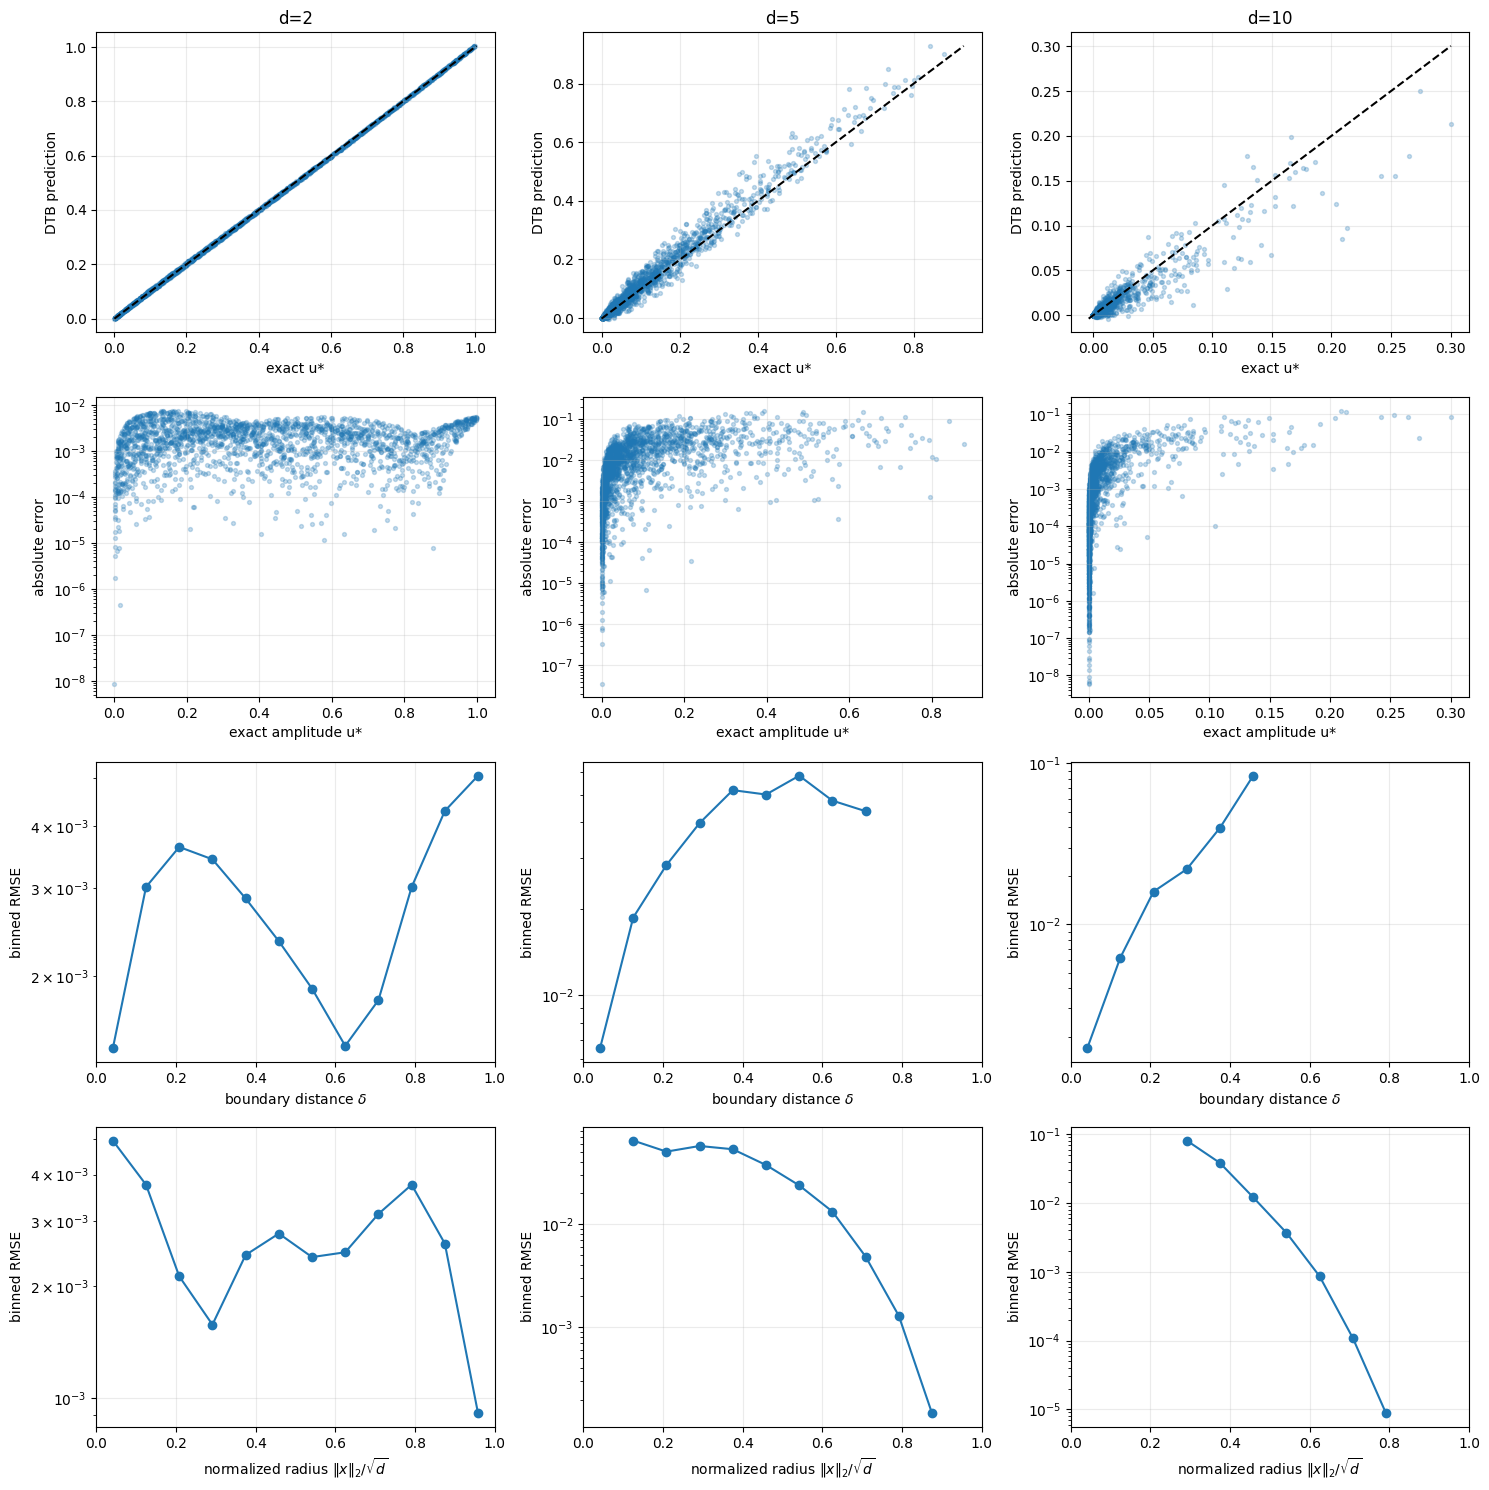

In [7]:
def binned_rmse(values, errors, edges):
    bin_index = np.clip(np.digitize(values, edges) - 1, 0, len(edges) - 2)
    centers = 0.5 * (edges[:-1] + edges[1:])
    rmse = np.full_like(centers, np.nan, dtype=float)
    for k in range(len(centers)):
        selected = bin_index == k
        if np.any(selected):
            rmse[k] = np.sqrt(np.mean(errors[selected] ** 2))
    return centers, rmse

edges = np.linspace(0.0, 1.0, 13)
fig, axes = plt.subplots(4, len(results), figsize=(15, 15))
for column, (d, result) in enumerate(results.items()):
    test = result['test']; reference = test['reference']; prediction = test['prediction']
    error = prediction - reference

    lower = min(reference.min(), prediction.min()); upper = max(reference.max(), prediction.max())
    axes[0, column].scatter(reference, prediction, s=8, alpha=.25)
    axes[0, column].plot([lower, upper], [lower, upper], 'k--', lw=1.5)
    axes[0, column].set(title=f'd={d}', xlabel='exact u*', ylabel='DTB prediction')

    axes[1, column].scatter(reference, np.maximum(np.abs(error), 1e-16), s=8, alpha=.25)
    axes[1, column].set(xlabel='exact amplitude u*', ylabel='absolute error', yscale='log')

    centers, rmse = binned_rmse(test['boundary_distance'], error, edges)
    axes[2, column].semilogy(centers, rmse, 'o-')
    axes[2, column].set(xlabel=r'boundary distance $\delta$', ylabel='binned RMSE', xlim=(0, 1))

    centers, rmse = binned_rmse(test['normalized_radius'], error, edges)
    axes[3, column].semilogy(centers, rmse, 'o-')
    axes[3, column].set(xlabel=r'normalized radius $\|x\|_2/\sqrt{d}$', ylabel='binned RMSE', xlim=(0, 1))

for axis in axes.flat:
    axis.grid(alpha=.25)
plt.tight_layout(); plt.show()

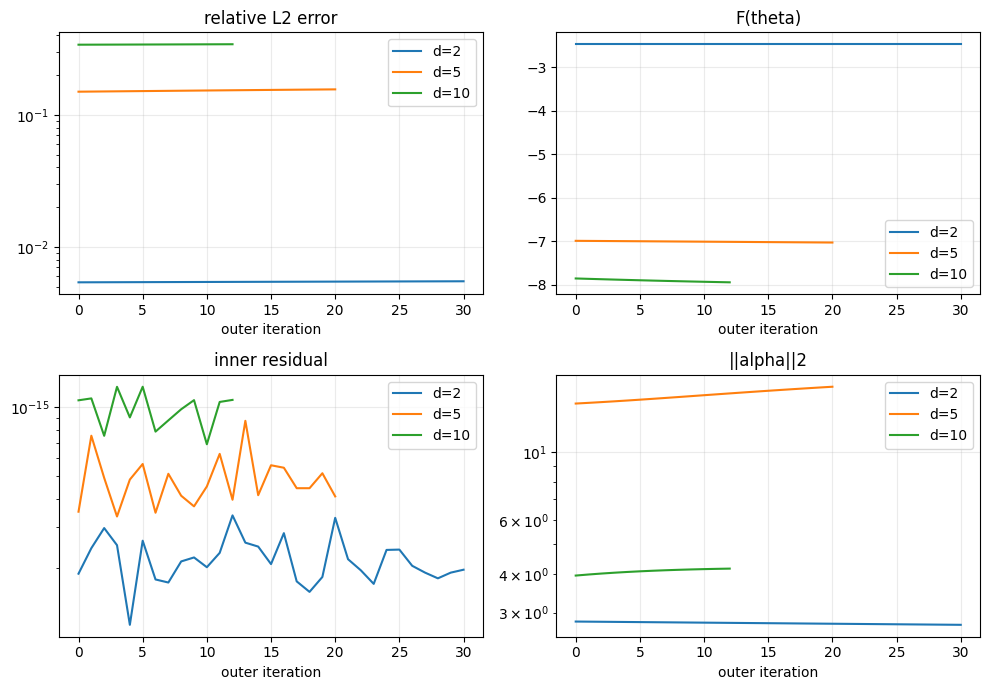

In [8]:
# Optimization diagnostics retained from the original experiment.
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
for d, result in results.items():
    h = result['history']; steps = [r['step'] for r in h]
    axes[0,0].semilogy(steps, [r['relative_l2'] for r in h], label=f'd={d}')
    axes[0,1].plot(steps, [r['F_theta'] for r in h], label=f'd={d}')
    axes[1,0].semilogy(steps, [r['inner_residual'] for r in h], label=f'd={d}')
    axes[1,1].semilogy(steps, [r['alpha_norm'] for r in h], label=f'd={d}')
for axis, title in zip(axes.flat, ['relative L2 error', 'F(theta)', 'inner residual', '||alpha||2']):
    axis.set(xlabel='outer iteration', title=title); axis.grid(alpha=.25); axis.legend()
plt.tight_layout(); plt.show()